In [8]:
import pickle
import numpy as np
import cv2
import os

In [9]:
data_dir = os.path.join(os.getcwd(), 'data')

with open(os.path.join(data_dir, 'images.p'), 'rb') as f:
    images = pickle.load(f)
with open(os.path.join(data_dir, 'labels.p'), 'rb') as f:
    labels = pickle.load(f)

print(f'Images shape: {images.shape}')
print(f'Labels shape: {labels.shape}')
print(f'Unique labels: {set(labels)}')

Images shape: (16082, 100, 100)
Labels shape: (16082,)
Unique labels: {'angry', 'sad', 'neutral', 'surprised', 'happy'}


In [10]:
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
num_classes = len(le.classes_)

print(f'Classes: {le.classes_}')
print(f'Number of classes: {num_classes}')
print(f'Label mapping: {dict(zip(le.classes_, range(num_classes)))}')

labels_categorical = to_categorical(labels_encoded, num_classes)

Classes: ['angry' 'happy' 'neutral' 'sad' 'surprised']
Number of classes: 5
Label mapping: {'angry': 0, 'happy': 1, 'neutral': 2, 'sad': 3, 'surprised': 4}


In [11]:
def preprocessing(img):
    img = cv2.equalizeHist(img)
    img = img.reshape(100, 100, 1)
    img = img / 255.0
    return img

images = np.array(list(map(preprocessing, images)))
print(f'Processed images shape: {images.shape}')

Processed images shape: (16082, 100, 100, 1)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    images, labels_categorical, test_size=0.2, random_state=42, stratify=labels_categorical
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')

Training set: 12865 samples
Test set: 3217 samples


In [13]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

def emotion_model():
    model = Sequential()

    model.add(Conv2D(32, (5, 5), input_shape=(100, 100, 1), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())

    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = emotion_model()
model.summary()

C:\Users\praty\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 96, 96, 32)          │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 96, 96, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 46, 46, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 46, 46, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 23, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 21, 21, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 21, 21, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 10, 10, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       3,277,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,404,677 (12.99 MB)

 Trainable params: 3,404,229 (12.99 MB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 238s 577ms/step - accuracy: 0.2609 - loss: 1.8320 - val_accuracy: 0.2415 - val_loss: 1.6022 - learning_rate: 0.0010
Epoch 2/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 256s 561ms/step - accuracy: 0.2836 - loss: 1.5771 - val_accuracy: 0.3199 - val_loss: 1.5213 - learning_rate: 0.0010
Epoch 3/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 262s 562ms/step - accuracy: 0.3063 - loss: 1.5472 - val_accuracy: 0.3401 - val_loss: 1.4979 - learning_rate: 0.0010
Epoch 4/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 260s 556ms/step - accuracy: 0.3238 - loss: 1.5144 - val_accuracy: 0.3482 - val_loss: 1.4772 - learning_rate: 0.0010
Epoch 5/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 266s 566ms/step - accuracy: 0.3330 - loss: 1.4947 - val_accuracy: 0.3590 - val_loss: 1.4406 - learning_rate: 0.0010
Epoch 6/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 225s 559ms/step - accuracy: 0.3435 - loss: 1.4770 - val_accuracy: 0.3687 - val_loss: 1.4537 - learning_rate: 0.0010
Epoch 7/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 238s 590ms/step - accura

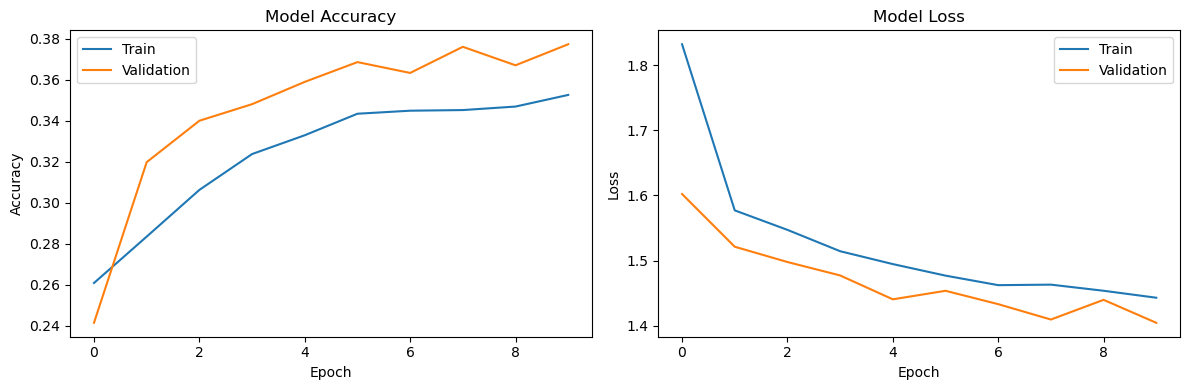

In [15]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

101/101 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00       602
       happy       0.30      0.97      0.46       820
     neutral       0.00      0.00      0.00       605
         sad       0.39      0.01      0.02       605
   surprised       0.74      0.71      0.72       585

    accuracy                           0.38      3217
   macro avg       0.29      0.34      0.24      3217
weighted avg       0.28      0.38      0.25      3217



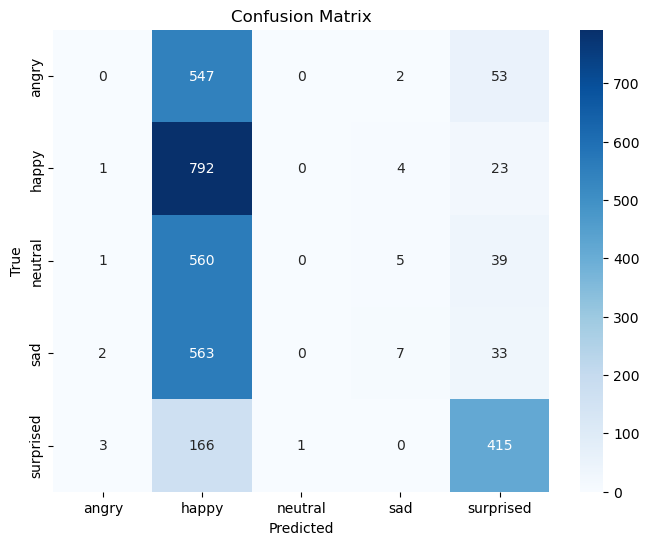

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [17]:
model.save('emotion_model.keras')

import pickle
with open(os.path.join(data_dir, 'label_encoder.p'), 'wb') as f:
    pickle.dump(le, f)

print('Model saved as emotion_model.keras')
print('Label encoder saved as data/label_encoder.p')

Model saved as emotion_model.keras
Label encoder saved as data/label_encoder.p
